<a href="https://colab.research.google.com/github/Koyel1234/ai-ml-learning-journey/blob/main/google_colab_notebooks/krish_naik/feature_engineering_notebooks/Feature_Engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# One Hot Encoding - Variables with Many Category

In [ ]:
import pandas as pd
import numpy as np

data = pd.read_csv('mercedesbenz.csv')

<IPython.core.display.Javascript object>

In [ ]:
data.head()

,ID,y,X0,X1,X2,X3,X4,X5,X6,X8,...,X375,X376,X377,X378,X379,X380,X382,X383,X384,X385
0,0,130.81,k,v,at,a,d,u,j,o,...,0,0,1,0,0,0,0,0,0,0
1,6,88.53,k,t,av,e,d,y,l,o,...,1,0,0,0,0,0,0,0,0,0
2,7,76.26,az,w,n,c,d,x,j,x,...,0,0,0,0,0,0,1,0,0,0
3,9,80.62,az,t,n,f,d,x,l,e,...,0,0,0,0,0,0,0,0,0,0
4,13,78.02,az,v,n,f,d,h,d,n,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
data = pd.read_csv('mercedesbenz.csv', usecols = ['X1','X2','X3','X4','X5','X6'])
data.head()

<IPython.core.display.Javascript object>

,X1,X2,X3,X4,X5,X6
0,v,at,a,d,u,j
1,t,av,e,d,y,l
2,w,n,c,d,x,j
3,t,n,f,d,x,l
4,v,n,f,d,h,d


In [ ]:
# let's have a look at how many labels each variable has

for col in data.columns:
    print(col,":",len(data[col].unique()),"labels")

X1 : 27 labels
X2 : 44 labels
X3 : 7 labels
X4 : 4 labels
X5 : 29 labels
X6 : 12 labels


In [ ]:
# let's examine how many columns we will obtain after one hot encoding these variables
pd.get_dummies(data, drop_first = True).shape

<IPython.core.display.Javascript object>

(4209, 117)

We can see that just from 6 initial categorical variables, we end up with 117 new variables.

What can wedo instead?

http://proceedings.mlr.press/v7/niculescu09/niculescu09.pdf In the winning solution of KDD 2019 cup: "Winning the KDD Cup Orange Challenge with Ensemble Selection the authors limit one hot encoding to the 10 most frequent labels of the variable. This means that they would make one binary variable for each of the 10 most frequent labels only. This is equivalent to grouping all the other labels under a new category, that in this case will dropped. Thus, the 10 new dummy variables indicate if one of the 10 most frequent labels is present (1) or not (0) for a particular observation.

How can we do that on python?

In [ ]:
# let's find top 10 most frequent categories for the variable X2
data.X2.value_counts().sort_values(ascending = False).head(20)

as    1659
ae     496
ai     415
m      367
ak     265
r      153
n      137
s       94
f       87
e       81
aq      63
ay      54
a       47
t       29
k       25
i       25
b       21
ao      20
z       19
ag      19
Name: X2, dtype: int64

In [ ]:
# let's make a list with the most frequent categories of the variable

top_10 = [x for x in data.X2.value_counts().sort_values(ascending = False).head(10).index]
top_10

['as', 'ae', 'ai', 'm', 'ak', 'r', 'n', 's', 'f', 'e']

In [ ]:
# and now we make 10 binary variables

for label in top_10:
    data[label] = np.where(data['X2'] == label, 1, 0)

data[['X2']+top_10].head(40)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,X2,as,ae,ai,m,ak,r,n,s,f,e
0,at,0,0,0,0,0,0,0,0,0,0
1,av,0,0,0,0,0,0,0,0,0,0
2,n,0,0,0,0,0,0,1,0,0,0
3,n,0,0,0,0,0,0,1,0,0,0
4,n,0,0,0,0,0,0,1,0,0,0
5,e,0,0,0,0,0,0,0,0,0,1
6,e,0,0,0,0,0,0,0,0,0,1
7,as,1,0,0,0,0,0,0,0,0,0
8,as,1,0,0,0,0,0,0,0,0,0
9,aq,0,0,0,0,0,0,0,0,0,0


In [ ]:
# get whole set of dummy varibles, for all the categorical variables

def one_hot_top_x(df, variable, top_x_labels):
    # function to create the dummy variables for the most frequent labels
    # we can vary the number of most frequent labels that we encode

    for label in top_x_labels:
        df[variable+'_'+label] = np.where(data[variable] == label, 1, 0)

# read the data again
data = pd.read_csv('mercedesbenz.csv',usecols=['X1','X2','X3','X4','X5','X6'])

# encode X2 into the 10 most frequent categories
one_hot_top_x(data, 'X2', top_10)
data.head()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,X1,X2,X3,X4,X5,X6,X2_as,X2_ae,X2_ai,X2_m,X2_ak,X2_r,X2_n,X2_s,X2_f,X2_e
0,v,at,a,d,u,j,0,0,0,0,0,0,0,0,0,0
1,t,av,e,d,y,l,0,0,0,0,0,0,0,0,0,0
2,w,n,c,d,x,j,0,0,0,0,0,0,1,0,0,0
3,t,n,f,d,x,l,0,0,0,0,0,0,1,0,0,0
4,v,n,f,d,h,d,0,0,0,0,0,0,1,0,0,0


In [ ]:
#find rhe 10 most frequent categories for X1
top_10 = [x for x in data.X1.value_counts().sort_values(ascending = False).head(10).index]
top_10

['aa', 's', 'b', 'l', 'v', 'r', 'i', 'a', 'c', 'o']

In [ ]:
# now create 10 most frequent dummy variables for X1
one_hot_top_x(data, 'X1', top_10)
data.head()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,X1,X2,X3,X4,X5,X6,X2_as,X2_ae,X2_ai,X2_m,...,X1_aa,X1_s,X1_b,X1_l,X1_v,X1_r,X1_i,X1_a,X1_c,X1_o
0,v,at,a,d,u,j,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
1,t,av,e,d,y,l,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,w,n,c,d,x,j,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,t,n,f,d,x,l,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,v,n,f,d,h,d,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0


# One Hot encoding of top variables

## Advantages
- Straightforward to implement
- Does not require hrs of variable exploration
- Does not expand massively the feature space (number of columns in the dataset)

## Disadvantages
- Does not add any information that may make the variable more predictive
- Does not keep the information of the ignored labels

Because it is not unusual that categorical variables have a few dominating categories and the remainning labels add mostly noise, this is a quite simple and straightforward approach that may be useful on many occassions.

It is worth nothing that the top 10 variables is a totally arbitrary number. You could also choose the top 5, or top 20.

This modelling was more than enough for the team to win the KDD 2009 cup. They did do some other powerful feature engineering as we will see in the following lectures, that improved the performance of the varioables dramatically.

# Missing Values

Life cycle of a Data Science Projects
1. Data Collection Strategy --- from company side, 3rd party API's, Surveys
2. Feature Engineering --- Handling Missing Values

Why are there Missing Values? Survey-- Depression Survey
1. They hesitate to pu down the information
2. Survey informations are not that valid
3. Men--Salary
4. Women--Age
5. People may have died--NAN

Data science projects --- Dataset should be collected from multiple sources

# What are differenr types of Missing values?

1. #### Missing Completely at Random, MCAR:
A variable is missing completrly at random (MCAR) if the probability of being missing is the same for all observations. When data is MCAR, there is absolutely no relationship between the data missing and any other values, observed or missing within the dataset. In other words those missing data points are a random subset of the data. There is nothing systematic going on that makes some data more likely to be missing than other.

If values for observations are completely missing at random, then disregarding those cases would not bias the inferences made.

Data that will be missing---
1) Continuous Data
2) Categorical Data




In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('titanic.csv')

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [ ]:
df['Embarked'].isnull()

0      False
1      False
2      False
3      False
4      False
       ...  
886    False
887    False
888    False
889    False
890    False
Name: Embarked, Length: 891, dtype: bool

In [ ]:
df[df['Embarked'].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


2. #### Missing Data not at Random (MNAR) : Systematic Missing Values

There is absolutely some relationship between the data missing and any other values, observed or missing within the dataset.

In [ ]:
import numpy as np

df['cabin_null'] = np.where(df['Cabin'].isnull(),1,0)

#find percentage of null values
df['cabin_null'].mean()

0.7710437710437711

In [ ]:
df['cabin_null']

0      1
1      0
2      1
3      0
4      1
      ..
886    1
887    0
888    1
889    0
890    1
Name: cabin_null, Length: 891, dtype: int32

In [ ]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'cabin_null'],
      dtype='object')

In [ ]:
df.groupby(['Survived'])['Cabin']

In [ ]:
df.groupby(['Survived'])['cabin_null'].mean()

Survived
0    0.876138
1    0.602339
Name: cabin_null, dtype: float64

3. #### Missing at Random (MAR)

Men--- hide their salary

Women--- hide their age

# All the techniques of handling missing values

1. Mean/Median/Mode replacement
2. Random Sample Imputation
3. Capturing NAN values with a new feature
4. End of Distruibution imputation
5. Arbitrary imputation
6. Frequent Categories imputation

# Mean/Median/Mode imputation

When should we apply this?

Mean/Median has the assumption that the data are missing completely at random (MCAR). We solve this by replacing the NAN with the most frequent occurance of the variables.

In [ ]:
df =pd.read_csv('titanic.csv',usecols=['Age','Fare','Survived'])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [ ]:
#let's go and see percentage of missing values
df.isnull().mean()

Survived    0.000000
Age         0.198653
Fare        0.000000
dtype: float64

In [ ]:
def impute_nan(df,variable,median):
    df[variable+"_median"]=df[variable].fillna(median)

In [ ]:
median= df.Age.median()
median

28.0

In [ ]:
impute_nan(df,'Age',median)
df.head()

,Survived,Age,Fare,Age_median
0,0,22.0,7.2500,22.0
1,1,38.0,71.2833,38.0
2,1,26.0,7.9250,26.0
3,1,35.0,53.1000,35.0
4,0,35.0,8.0500,35.0


In [ ]:
print(df['Age'].std())
print(df['Age_median'].std())

14.526497332334044
13.019696550973194


In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

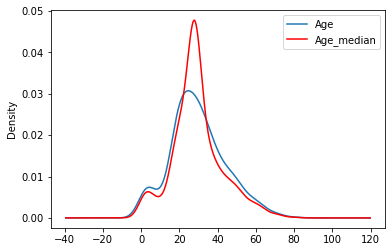

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111)
df['Age'].plot(kind = 'kde', ax = ax)
df.Age_median.plot(kind = 'kde', ax = ax, color = 'red')
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc = 'best')

## Advantages and Disadvantages of Mean/Median/Mode imputation

### Advantages
1. Easy to implement (Robust to outliers)
2. Faster way to obtain the complete dataset

### Disadvantages
1. Change or distortion in the original variance
2. Impacts Correlation

# Random Sample Imputation

Aim: Random Sample Imputation consists of taking random observation from the dataset and we use this observation to replace NAN values.

##### When should it be used?
It assumes that the data are missing completely at random (MCAR)

In [ ]:
import pandas as pd
df=pd.read_csv('titanic.csv',usecols=['Age','Fare','Survived'])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [ ]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [ ]:
df.isnull().mean()

Survived    0.000000
Age         0.198653
Fare        0.000000
dtype: float64

In [ ]:
df['Age'].isnull().sum()

177

In [ ]:
df['Age'].dropna()

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
885    39.0
886    27.0
887    19.0
889    26.0
890    32.0
Name: Age, Length: 714, dtype: float64

In [ ]:
df['Age'].dropna().sample()

453    49.0
Name: Age, dtype: float64

In [ ]:
df['Age'].dropna().sample(df['Age'].isnull().sum(),random_state=0)

423    28.00
177    50.00
305     0.92
292    36.00
889    26.00
       ...  
539    22.00
267    25.00
352    15.00
99     34.00
689    15.00
Name: Age, Length: 177, dtype: float64

In [ ]:
df[df['Age'].isnull()].index

Int64Index([  5,  17,  19,  26,  28,  29,  31,  32,  36,  42,
            ...
            832, 837, 839, 846, 849, 859, 863, 868, 878, 888],
           dtype='int64', length=177)

In [ ]:
def impute_nan(df,variable,median):
    df[variable+"_median"]=df[variable].fillna(median)
    df[variable+"_random"]=df[variable]
    #it will have the random sample to fill the na
    random_sample=df[variable].dropna().sample(df[variable].isnull().sum(),random_state=0)
    ## pandas needs to have same index in order to merge the dataset
    random_sample.index= df[df[variable].isnull()].index
    df.loc[df[variable].isnull(),variable+"_random"]=random_sample

In [ ]:
median=df.Age.median()

In [ ]:
median

28.0

In [ ]:
impute_nan(df,"Age",median)

In [ ]:
df.head()

,Survived,Age,Fare,Age_median,Age_random
0,0,22.0,7.2500,22.0,22.0
1,1,38.0,71.2833,38.0,38.0
2,1,26.0,7.9250,26.0,26.0
3,1,35.0,53.1000,35.0,35.0
4,0,35.0,8.0500,35.0,35.0


In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

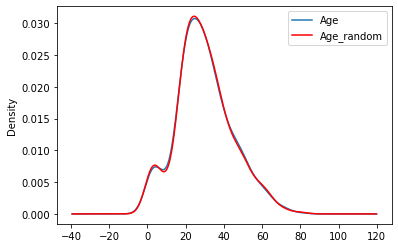

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111)
df['Age'].plot(kind = 'kde', ax = ax)
df.Age_random.plot(kind = 'kde', ax = ax, color = 'red')
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc = 'best')

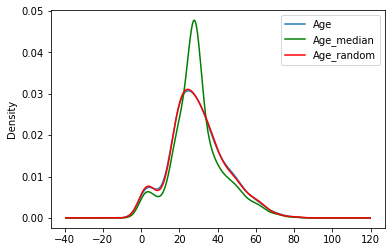

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111)
df['Age'].plot(kind = 'kde', ax = ax)
df.Age_median.plot(kind = 'kde', ax = ax, color = 'green')
df.Age_random.plot(kind = 'kde', ax = ax, color = 'red')
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc = 'best')

In [ ]:
df.Age.median()

28.0

In [ ]:
df.Age.mean()

29.69911764705882

In [ ]:
df['Age'].fillna(df.Age.median(),inplace=True)

In [ ]:
df.head(10)

,Survived,Age,Fare,Age_NAN
0,0,22.0,7.2500,0
1,1,38.0,71.2833,0
2,1,26.0,7.9250,0
3,1,35.0,53.1000,0
4,0,35.0,8.0500,0
5,0,28.0,8.4583,1
6,0,54.0,51.8625,0
7,0,2.0,21.0750,0
8,1,27.0,11.1333,0
9,1,14.0,30.0708,0


## Advantages and Disadvantages of Random Sample imputation

### Advantages
1. Easy to implement
2. Captures the importance of missing values

### Disadvantages
1. Every situation randomnesss won't work

# Capturing NAN values with a new feature
It works well if the data are not missing completely at random.

In [ ]:
df=pd.read_csv('titanic.csv', usecols=['Age','Fare','Survived'])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [ ]:
df['Age_NAN']=np.where(df['Age'].isnull(),1,0)

<IPython.core.display.Javascript object>

In [ ]:
df.head()

,Survived,Age,Fare,Age_NAN
0,0,22.0,7.2500,0
1,1,38.0,71.2833,0
2,1,26.0,7.9250,0
3,1,35.0,53.1000,0
4,0,35.0,8.0500,0


## Advantages and Disadvantages of Capturing NAN values with a new feature

### Advantages
1. Easy to implement
2. There is less distortion in variance

### Disadvantages
1. Creating additional features (Curse of Dimentionality)

# End of Distribution Imputation

In [ ]:
df=pd.read_csv('titanic.csv', usecols=['Age','Fare','Survived'])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


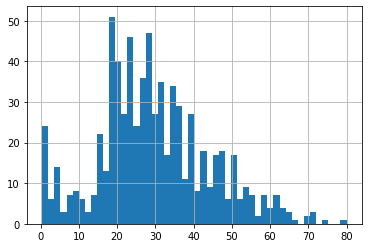

In [ ]:
df.Age.hist(bins=50)

In [ ]:
df.Age.mean()

29.69911764705882

In [ ]:
extreme = df.Age.mean()+3*df.Age.std()
print(extreme)


73.27860964406095


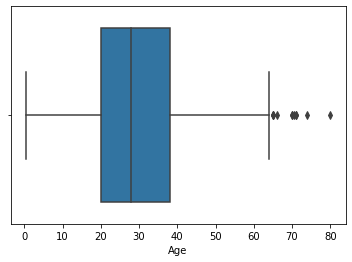

In [ ]:
import seaborn as sns
sns.boxplot('Age',data=df)

In [ ]:
def impute_nan(df,variable,median,extreme):
    df[variable+"_end_distribution"]=df[variable].fillna(extreme)
    df[variable].fillna(median,inplace=True)

In [ ]:
impute_nan(df,'Age',df.Age.median(),extreme)

In [ ]:
df.head()

,Survived,Age,Fare,Age_end_distribution
0,0,22.0,7.2500,22.0
1,1,38.0,71.2833,38.0
2,1,26.0,7.9250,26.0
3,1,35.0,53.1000,35.0
4,0,35.0,8.0500,35.0


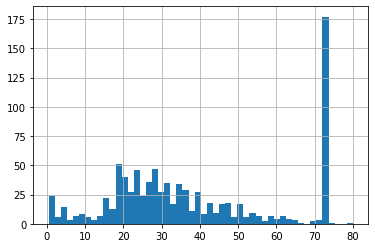

In [ ]:
df.Age_end_distribution.hist(bins=50)

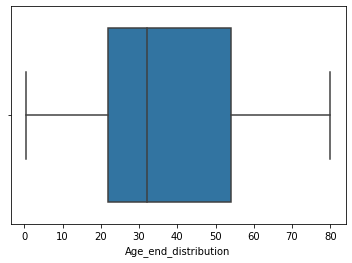

In [ ]:
sns.boxplot('Age_end_distribution',data=df)

## Advantages and Disadvantages of Capturing NAN values with a new feature

### Advantages
1. Easy to implement
2. Captures the importance of missingness if there is one

### Disadvantages
1. Distorts the original distribution of the variable
2. If missingness is not important, it may mask the predictive power of the original variable by distorting its distribution.
3. If the number of NA is big, it will mask true outliers in the distribution.
4. If the number of NA is small, the replaced NA may be considered an outlier and pre-processed in a subsequent feature            engineering.

# Arbitrary Value Imputation

This technique was derived from kaggle competition.
It consists of replacing NAN by an arbitrary value.

In [ ]:
import pandas as pd

In [ ]:
df=pd.read_csv('titanic.csv', usecols=['Age','Fare','Survived'])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [ ]:
def imput_nan(df,variable):
    df[variable+'_hundred']=df[variable].fillna(100)

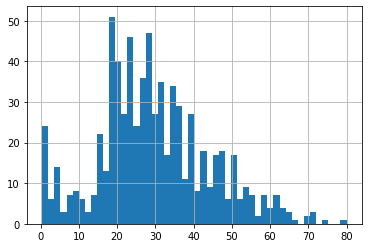

In [ ]:
df.Age.hist(bins=50)

In [ ]:
def imput_nan(df,variable):
    df[variable+'_zeros']=df[variable].fillna(0)
    df[variable+'_hundred']=df[variable].fillna(100)

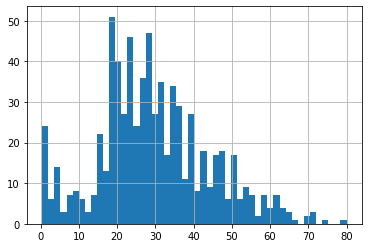

In [ ]:
df.Age.hist(bins=50)

### Arbitrary Values
- It should be more frequenly present.

## Advantages and Disadvantages of Arbitrary Value Imputation

### Advantages
1. Easy to implement
2. Captures the importance of missingness if there is one

### Disadvantages
1. Distorts the original distribution of the variable
2. If missingness is not important, it may mask the predictive power of the original variable by distorting its distribution.
3. Hard to decide which value to use.

## *How to handle categorical missing values?*

# Frequent Category Imputation

In [ ]:
df = pd.read_csv('train_house_prediction.csv')

In [ ]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [ ]:
df = pd.read_csv('train_house_prediction.csv', usecols = ['BsmtQual','FireplaceQu','GarageType','SalePrice'])

In [ ]:
df.head()

,BsmtQual,FireplaceQu,GarageType,SalePrice
0,Gd,NaN,Attchd,208500
1,Gd,TA,Attchd,181500
2,Gd,TA,Attchd,223500
3,TA,Gd,Detchd,140000
4,Gd,TA,Attchd,250000


In [ ]:
df.shape

(1460, 4)

In [ ]:
df.isnull().sum()

BsmtQual        37
FireplaceQu    690
GarageType      81
SalePrice        0
dtype: int64

In [ ]:
df.isnull().mean()

BsmtQual       0.025342
FireplaceQu    0.472603
GarageType     0.055479
SalePrice      0.000000
dtype: float64

In [ ]:
df.isnull().mean().sort_values(ascending=True)

SalePrice      0.000000
BsmtQual       0.025342
GarageType     0.055479
FireplaceQu    0.472603
dtype: float64

### Compute the frequency with every feature

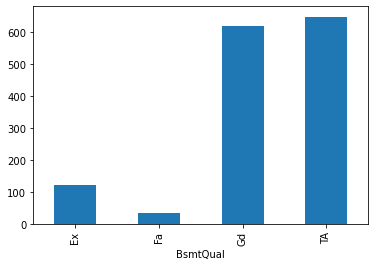

In [ ]:
df.groupby(['BsmtQual'])['BsmtQual'].count().plot.bar()

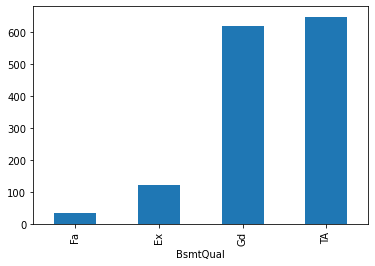

In [ ]:
df.groupby(['BsmtQual'])['BsmtQual'].count().sort_values(ascending= True).plot.bar()

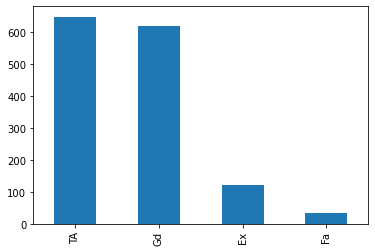

In [ ]:
# another way

df['BsmtQual'].value_counts().plot.bar()

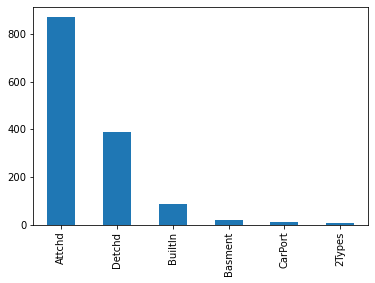

In [ ]:
df['GarageType'].value_counts().plot.bar()

In [ ]:
df['GarageType'].value_counts()[0]

870

In [ ]:
df['GarageType'].value_counts()

Attchd     870
Detchd     387
BuiltIn     88
Basment     19
CarPort      9
2Types       6
Name: GarageType, dtype: int64

In [ ]:
type(df['GarageType'].value_counts())

pandas.core.series.Series

In [ ]:
df['GarageType'].value_counts().index

Index(['Attchd', 'Detchd', 'BuiltIn', 'Basment', 'CarPort', '2Types'], dtype='object')

In [ ]:
df['GarageType'].value_counts().index[0]

'Attchd'

In [ ]:
df['GarageType'].mode()   #another way

0    Attchd
dtype: object

In [ ]:
df['GarageType'].mode()[0]

'Attchd'

In [ ]:
def impute_nan(df,variable):
    most_frequent_category = df[variable].value_counts().index[0]
    df[variable].fillna(most_frequent_category, inplace = True)

In [ ]:
for feature in ['BsmtQual','FireplaceQu','GarageType']:
    impute_nan(df,feature)

In [ ]:
df.head()

,BsmtQual,FireplaceQu,GarageType,SalePrice
0,Gd,Gd,Attchd,208500
1,Gd,TA,Attchd,181500
2,Gd,TA,Attchd,223500
3,TA,Gd,Detchd,140000
4,Gd,TA,Attchd,250000


In [ ]:
df.isnull().sum()

BsmtQual       0
FireplaceQu    0
GarageType     0
SalePrice      0
dtype: int64

In [ ]:
df.isnull().mean()

BsmtQual       0.0
FireplaceQu    0.0
GarageType     0.0
SalePrice      0.0
dtype: float64

## Advantages and Disadvantages of Frequent Category Imputation

### Advantages
1. Easy to implement
2. Faster way to implement

### Disadvantages
1. Since we are using the more frequenly labels, it may use then in as over represented way, if there are many NANs.
2. It distorts the relation of the most frequent label.

# Adding a Variable to Capture NAN

In [ ]:
df = pd.read_csv('train_house_prediction.csv', usecols = ['BsmtQual','FireplaceQu','GarageType','SalePrice'])

In [ ]:
df.head()

,BsmtQual,FireplaceQu,GarageType,SalePrice
0,Gd,NaN,Attchd,208500
1,Gd,TA,Attchd,181500
2,Gd,TA,Attchd,223500
3,TA,Gd,Detchd,140000
4,Gd,TA,Attchd,250000


In [ ]:
import numpy as np
df['BsmtQual_Var']=np.where(df['BsmtQual'].isnull(),1,0)

In [ ]:
df.head()

,BsmtQual,FireplaceQu,GarageType,SalePrice,BsmtQual_Var
0,Gd,NaN,Attchd,208500,0
1,Gd,TA,Attchd,181500,0
2,Gd,TA,Attchd,223500,0
3,TA,Gd,Detchd,140000,0
4,Gd,TA,Attchd,250000,0


In [ ]:
frequent = df['BsmtQual'].mode()[0]

In [ ]:
frequent

'TA'

In [ ]:
df['BsmtQual'].fillna(frequent,inplace=True)

In [ ]:
df.head()

,BsmtQual,FireplaceQu,GarageType,SalePrice,BsmtQual_Var
0,Gd,NaN,Attchd,208500,0
1,Gd,TA,Attchd,181500,0
2,Gd,TA,Attchd,223500,0
3,TA,Gd,Detchd,140000,0
4,Gd,TA,Attchd,250000,0


In [ ]:
df['FireplaceQu_Var'] = np.where(df['FireplaceQu'].isnull(),1,0)
frequent = df['FireplaceQu'].mode()[0]
df['FireplaceQu'].fillna(frequent,inplace=True)

In [ ]:
df.head()

,BsmtQual,FireplaceQu,GarageType,SalePrice,BsmtQual_Var,FireplaceQu_Var
0,Gd,Gd,Attchd,208500,0,1
1,Gd,TA,Attchd,181500,0,0
2,Gd,TA,Attchd,223500,0,0
3,TA,Gd,Detchd,140000,0,0
4,Gd,TA,Attchd,250000,0,0


## Suppose you have more frequent categories, we just replace NAN with a new category

In [ ]:
df = pd.read_csv('train_house_prediction.csv', usecols = ['BsmtQual','FireplaceQu','GarageType','SalePrice'])

In [ ]:
df.head()

,BsmtQual,FireplaceQu,GarageType,SalePrice
0,Gd,NaN,Attchd,208500
1,Gd,TA,Attchd,181500
2,Gd,TA,Attchd,223500
3,TA,Gd,Detchd,140000
4,Gd,TA,Attchd,250000


In [ ]:
def imput_nan(df,variable):
    df[variable+'nwevar']=np.where(df[variable].isnull(),"Missing",df[variable])

In [ ]:
for feature in ['BsmtQual','FireplaceQu','GarageType']:
    imput_nan(df,feature)

In [ ]:
df.head()

,BsmtQual,FireplaceQu,GarageType,SalePrice,BsmtQualnwevar,FireplaceQunwevar,GarageTypenwevar
0,Gd,NaN,Attchd,208500,Gd,Missing,Attchd
1,Gd,TA,Attchd,181500,Gd,TA,Attchd
2,Gd,TA,Attchd,223500,Gd,TA,Attchd
3,TA,Gd,Detchd,140000,TA,Gd,Detchd
4,Gd,TA,Attchd,250000,Gd,TA,Attchd


In [ ]:
df.drop(['BsmtQual','FireplaceQu','GarageType'],axis=1)

,SalePrice,BsmtQualnwevar,FireplaceQunwevar,GarageTypenwevar
0,208500,Gd,Missing,Attchd
1,181500,Gd,TA,Attchd
2,223500,Gd,TA,Attchd
3,140000,TA,Gd,Detchd
4,250000,Gd,TA,Attchd
...,...,...,...,...
1455,175000,Gd,TA,Attchd
1456,210000,Gd,TA,Attchd
1457,266500,TA,Gd,Attchd
1458,142125,TA,Missing,Attchd


# Handling Categorical Features

In [ ]:
import pandas as pd

In [ ]:
df=pd.read_csv('titanic.csv',usecols=['Sex'])
df.head()

,Sex
0,male
1,female
2,female
3,female
4,male


In [ ]:
pd.get_dummies(df).head()

,Sex_female,Sex_male
0,0,1
1,1,0
2,1,0
3,1,0
4,0,1


In [ ]:
pd.get_dummies(df, drop_first=True).head()

,Sex_male
0,1
1,0
2,0
3,0
4,1


In [ ]:
df=pd.read_csv('titanic.csv',usecols=['Embarked'])
df.head()

,Embarked
0,S
1,C
2,S
3,S
4,S


In [ ]:
df['Embarked'].unique()

array(['S', 'C', 'Q', nan], dtype=object)

In [ ]:
df.dropna(inplace=True)

In [ ]:
df.head()

,Embarked
0,S
1,C
2,S
3,S
4,S


In [ ]:
pd.get_dummies(df, drop_first=False).head()

,Embarked_C,Embarked_Q,Embarked_S
0,0,0,1
1,1,0,0
2,0,0,1
3,0,0,1
4,0,0,1


In [ ]:
pd.get_dummies(df, drop_first=True).head()

,Embarked_Q,Embarked_S
0,0,1
1,0,0
2,0,1
3,0,1
4,0,1


### Onehot encoding with many categories in a feature

In [ ]:
df=pd.read_csv('mercedesbenz.csv')
df.head()

,ID,y,X0,X1,X2,X3,X4,X5,X6,X8,...,X375,X376,X377,X378,X379,X380,X382,X383,X384,X385
0,0,130.81,k,v,at,a,d,u,j,o,...,0,0,1,0,0,0,0,0,0,0
1,6,88.53,k,t,av,e,d,y,l,o,...,1,0,0,0,0,0,0,0,0,0
2,7,76.26,az,w,n,c,d,x,j,x,...,0,0,0,0,0,0,1,0,0,0
3,9,80.62,az,t,n,f,d,x,l,e,...,0,0,0,0,0,0,0,0,0,0
4,13,78.02,az,v,n,f,d,h,d,n,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df=pd.read_csv('mercedesbenz.csv', usecols = ["X0","X1","X2","X3","X4","X5","X6"])
df.head()

,X0,X1,X2,X3,X4,X5,X6
0,k,v,at,a,d,u,j
1,k,t,av,e,d,y,l
2,az,w,n,c,d,x,j
3,az,t,n,f,d,x,l
4,az,v,n,f,d,h,d


In [ ]:
for i in df.columns:
    print(df[i].value_counts())

z     360
ak    349
y     324
ay    313
t     306
x     300
o     269
f     227
n     195
w     182
j     181
az    175
aj    151
s     106
ap    103
h      75
d      73
al     67
v      36
af     35
m      34
ai     34
e      32
ba     27
at     25
a      21
ax     19
am     18
aq     18
i      18
u      17
aw     16
l      16
ad     14
au     11
b      11
k      11
as     10
r      10
bc      6
ao      4
c       3
aa      2
q       2
g       1
ab      1
ac      1
Name: X0, dtype: int64
aa    833
s     598
b     592
l     590
v     408
r     251
i     203
a     143
c     121
o      82
w      52
z      46
u      37
e      33
m      32
t      31
h      29
f      23
y      23
j      22
n      19
k      17
p       9
g       6
ab      3
d       3
q       3
Name: X1, dtype: int64
as    1659
ae     496
ai     415
m      367
ak     265
r      153
n      137
s       94
f       87
e       81
aq      63
ay      54
a       47
t       29
i       25
k       25
b       21
ao      20
ag      19
z    

In [ ]:
df['X0'].value_counts()

z     360
ak    349
y     324
ay    313
t     306
x     300
o     269
f     227
n     195
w     182
j     181
az    175
aj    151
s     106
ap    103
h      75
d      73
al     67
v      36
af     35
m      34
ai     34
e      32
ba     27
at     25
a      21
ax     19
am     18
aq     18
i      18
u      17
aw     16
l      16
ad     14
au     11
b      11
k      11
as     10
r      10
bc      6
ao      4
c       3
aa      2
q       2
g       1
ab      1
ac      1
Name: X0, dtype: int64

In [ ]:
df['X0'].unique()

array(['k', 'az', 't', 'al', 'o', 'w', 'j', 'h', 's', 'n', 'ay', 'f', 'x',
       'y', 'aj', 'ak', 'am', 'z', 'q', 'at', 'ap', 'v', 'af', 'a', 'e',
       'ai', 'd', 'aq', 'c', 'aa', 'ba', 'as', 'i', 'r', 'b', 'ax', 'bc',
       'u', 'ad', 'au', 'm', 'l', 'aw', 'ao', 'ac', 'g', 'ab'],
      dtype=object)

In [ ]:
len(df['X0'].unique())

47

In [ ]:
for i in df.columns:
    print(len(df[i].unique()))

47
27
44
7
4
29
12


In [ ]:
df.X1.value_counts()

aa    833
s     598
b     592
l     590
v     408
r     251
i     203
a     143
c     121
o      82
w      52
z      46
u      37
e      33
m      32
t      31
h      29
f      23
y      23
j      22
n      19
k      17
p       9
g       6
ab      3
d       3
q       3
Name: X1, dtype: int64

In [ ]:
df.X1.value_counts().sort_values(ascending=False).head(10) #top 10 most frequent categories in column X1

aa    833
s     598
b     592
l     590
v     408
r     251
i     203
a     143
c     121
o      82
Name: X1, dtype: int64

In [ ]:
lst_10=df.X1.value_counts().sort_values(ascending=False).head(10).index

In [ ]:
lst_10

Index(['aa', 's', 'b', 'l', 'v', 'r', 'i', 'a', 'c', 'o'], dtype='object')

In [ ]:
lst_10=list(lst_10)

In [ ]:
lst_10

['aa', 's', 'b', 'l', 'v', 'r', 'i', 'a', 'c', 'o']

In [ ]:
for categories in lst_10:
    df[categories]=np.where(df['X1']==categories,1,0)

In [ ]:
df[lst_10]

,aa,s,b,l,v,r,i,a,c,o
0,0,0,0,0,1,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
4204,0,1,0,0,0,0,0,0,0,0
4205,0,0,0,0,0,0,0,0,0,1
4206,0,0,0,0,1,0,0,0,0,0
4207,0,0,0,0,0,1,0,0,0,0


In [ ]:
lst_10.append('X1')

In [ ]:
df[lst_10]

,aa,s,b,l,v,r,i,a,c,o,X1
0,0,0,0,0,1,0,0,0,0,0,v
1,0,0,0,0,0,0,0,0,0,0,t
2,0,0,0,0,0,0,0,0,0,0,w
3,0,0,0,0,0,0,0,0,0,0,t
4,0,0,0,0,1,0,0,0,0,0,v
...,...,...,...,...,...,...,...,...,...,...,...
4204,0,1,0,0,0,0,0,0,0,0,s
4205,0,0,0,0,0,0,0,0,0,1,o
4206,0,0,0,0,1,0,0,0,0,0,v
4207,0,0,0,0,0,1,0,0,0,0,r


# Ordinal Number Encoding

Grading System ---  A,B,C,D,F <br>
A-1<br>
B-2<br>
C-3<br>
D-4<br>
E-5<br>

Experience of a Batsman

A-10 -- 1<br>
B-5 -- 2<br>
C-3 -- 3<br>

Weekdays and Weekends : Mon,Tues,Wed,Thurs,Fri,Sat,Sun<br>

Sun--1<br>
Sat--2<br>
.<br>
.<br>
.<br>
Mon--7

In [ ]:
import datetime

In [ ]:
today_date=datetime.datetime.today()

In [ ]:
today_date

datetime.datetime(2021, 6, 8, 13, 14, 17, 550195)

In [ ]:
today_date-datetime.timedelta(3)

datetime.datetime(2021, 6, 5, 13, 14, 17, 550195)

In [ ]:
### list comprehension
[today_date-datetime.timedelta(x) for x in range(0,15)]

[datetime.datetime(2021, 6, 8, 13, 14, 17, 550195),
 datetime.datetime(2021, 6, 7, 13, 14, 17, 550195),
 datetime.datetime(2021, 6, 6, 13, 14, 17, 550195),
 datetime.datetime(2021, 6, 5, 13, 14, 17, 550195),
 datetime.datetime(2021, 6, 4, 13, 14, 17, 550195),
 datetime.datetime(2021, 6, 3, 13, 14, 17, 550195),
 datetime.datetime(2021, 6, 2, 13, 14, 17, 550195),
 datetime.datetime(2021, 6, 1, 13, 14, 17, 550195),
 datetime.datetime(2021, 5, 31, 13, 14, 17, 550195),
 datetime.datetime(2021, 5, 30, 13, 14, 17, 550195),
 datetime.datetime(2021, 5, 29, 13, 14, 17, 550195),
 datetime.datetime(2021, 5, 28, 13, 14, 17, 550195),
 datetime.datetime(2021, 5, 27, 13, 14, 17, 550195),
 datetime.datetime(2021, 5, 26, 13, 14, 17, 550195),
 datetime.datetime(2021, 5, 25, 13, 14, 17, 550195)]

In [ ]:
days=[today_date-datetime.timedelta(x) for x in range(0,15)]

In [ ]:
import pandas as pd
data=pd.DataFrame(days)
data.columns=["Days"]

In [ ]:
data.head()

,Days
0,2021-06-08 13:14:17.550195
1,2021-06-07 13:14:17.550195
2,2021-06-06 13:14:17.550195
3,2021-06-05 13:14:17.550195
4,2021-06-04 13:14:17.550195


In [ ]:
data['Days']

0    2021-06-08 13:14:17.550195
1    2021-06-07 13:14:17.550195
2    2021-06-06 13:14:17.550195
3    2021-06-05 13:14:17.550195
4    2021-06-04 13:14:17.550195
5    2021-06-03 13:14:17.550195
6    2021-06-02 13:14:17.550195
7    2021-06-01 13:14:17.550195
8    2021-05-31 13:14:17.550195
9    2021-05-30 13:14:17.550195
10   2021-05-29 13:14:17.550195
11   2021-05-28 13:14:17.550195
12   2021-05-27 13:14:17.550195
13   2021-05-26 13:14:17.550195
14   2021-05-25 13:14:17.550195
Name: Days, dtype: datetime64[ns]

In [ ]:
data['Days'].dt.year

0     2021
1     2021
2     2021
3     2021
4     2021
5     2021
6     2021
7     2021
8     2021
9     2021
10    2021
11    2021
12    2021
13    2021
14    2021
Name: Days, dtype: int64

In [ ]:
data['Days'].dt.month

0     6
1     6
2     6
3     6
4     6
5     6
6     6
7     6
8     5
9     5
10    5
11    5
12    5
13    5
14    5
Name: Days, dtype: int64

In [ ]:
data['Days'].dt.week

0     23
1     23
2     22
3     22
4     22
5     22
6     22
7     22
8     22
9     21
10    21
11    21
12    21
13    21
14    21
Name: Days, dtype: int64

In [ ]:
data['Days'].dt.day

0      8
1      7
2      6
3      5
4      4
5      3
6      2
7      1
8     31
9     30
10    29
11    28
12    27
13    26
14    25
Name: Days, dtype: int64

In [ ]:
data['Days'].dt.hour

0     13
1     13
2     13
3     13
4     13
5     13
6     13
7     13
8     13
9     13
10    13
11    13
12    13
13    13
14    13
Name: Days, dtype: int64

In [ ]:
data['Days'].dt.minute

0     14
1     14
2     14
3     14
4     14
5     14
6     14
7     14
8     14
9     14
10    14
11    14
12    14
13    14
14    14
Name: Days, dtype: int64

In [ ]:
data['Days'].dt.weekday

0     1
1     0
2     6
3     5
4     4
5     3
6     2
7     1
8     0
9     6
10    5
11    4
12    3
13    2
14    1
Name: Days, dtype: int64

In [ ]:
data['Days'].dt.weekday_name

AttributeError: 'DatetimeProperties' object has no attribute 'weekday_name'